# 01_INR_Image_Superresolution

Gonzalo Cazorla Sánchez


El objetivo es entrenar un modelo neuronal con capas lineales (MLP) para que aprenda esta imagen:
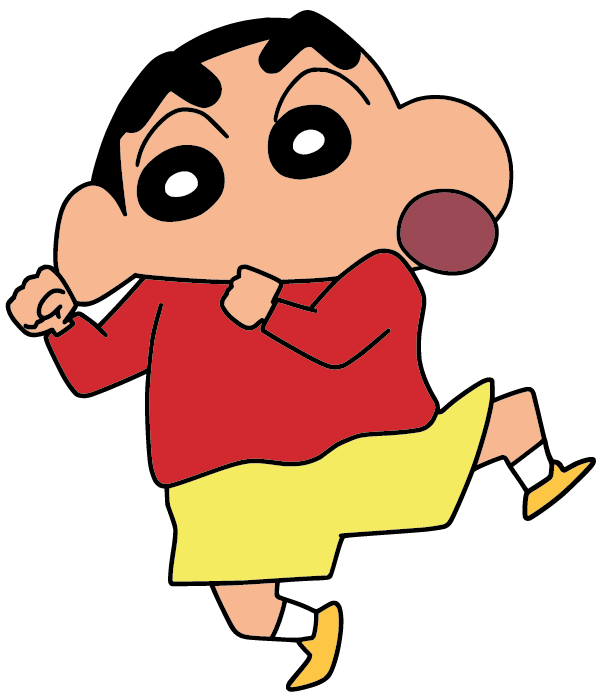

La imagen está disponible para ser descargada junto a este cuaderno (no hay que intentar extraerla del cuaderno). Para simplificar la práctica, la imagen se reducirá a un tamaño 35x30.

El modelo neuronal tiene que servir para reproducir la imagen sin necesidad de la propia imagen una vez entrenado. Se debe tener en cuenta que una imagen son colores asociados a una posición y crear un sistema en base a dicha relación.

Este problema tiene una dificultad asociada al comportamiento de los MLPs. Los MLPS son buenos aprendiendo funciones *suaves*. El problema es que una imagen es propensa a tener cambios bruscos. Por ejemplo, inmediatamente junto al color negro (\[0,0,0\] en RGB) puede ir el color blanco (\[255,255,255\] en RGB). Estas variaciones son denominamas variaciones de alta frecuencia y el MLP no es muy eficiente aprendiendo a representarlas. Para facilitar su aprendizaje podemos codificar la entrada del MLP usando una función como la siguiente que habitualmente denominamos codificación posicional (*positional encoding*):

$$\gamma(\mathbf{x})=[\gamma(x_{1}), \gamma(x_{2}),..,\gamma(x_{n})]$$ con $$\mathbf{x} \in [0,1]^n$$

$$\gamma(x_{i}) = [x_{i}, sin(2^{0}\pi x_{i}), cos(2^{0}\pi x_{i}), sin (2^{1}\pi x_{i}), cos(2^{1}\pi x_{i}),..., sin(2^{L-1}\pi x_{i}), cos(2^{L-1}\pi x_{i})]$$

Aquí está ya programado como un módulo de PyTorch :)

In [2]:
# Detectar si hay GPU disponible (CUDA) o usar CPU si no
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f'Usando dispositivo: {device}')

Usando dispositivo: cuda


In [1]:
import torch
import torch.nn as nn
import math
import matplotlib.pyplot as plt
from torchvision.io import decode_image
from torchvision.utils import save_image
from torchvision.transforms.functional import resize
from tqdm import tqdm
import csv
import os
from torch.utils.data import Dataset, DataLoader
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [3]:
class Positional_Encoder(nn.Module):
    def __init__(self, L = 10, include_input=True, device='cpu'):
        """
        Args:
            L (int): Número de frecuencias.
            include_input (bool): Si incluir la coordenada original en el output.
        """
        super(Positional_Encoder, self).__init__()
        self.include_input = include_input
        self.device = device
        self.freq_bands = 2. ** torch.linspace(0., L - 1, L, device=self.device)

    def forward(self, x):
        """
        Args:
          x (tensor): tensor de forma (..., dims) ej. (N,3) para coordenadas 3D
        """
        out = [x] if self.include_input else []
        for freq in self.freq_bands:
            out.append(torch.sin(freq * x * math.pi))
            out.append(torch.cos(freq * x * math.pi))
        return torch.cat(out, dim=-1)

    def get_output_dim(self, input_dim):
        return input_dim+2*input_dim*self.freq_bands.shape[0]

Recomiendo usarlo con los valores por defecto (L=10, include_input=True).

Intuitivamente la codificación posicional descompone los valores de entrada a una representación de la misma información en diversas frecuencias permitiendo que distintas entradas del MLP atiendan a distintos niveles de detalle.

Una vez entrenado el MLP. se requiere usarlo para generar la imagen al doble de resolución (70x60).

El cuaderno debe entregarse con los experimentos que se consideren más relevantes para resolver el problema.

El cuaderno entregado debe llamarse ApellidosNombrePractica1Ejercicio2.ipynb

Consejos:

*   Normalizar los colores de la imagen al rango [0,1].
*   Empezar trabajando con una resolución más pequeña o en escala de grises para simplificar el problema.

Comencemos con la función que extrae los datos de la imagen:

In [18]:
working_path = '/content/drive/MyDrive/PIA/PRACTICA1EJ2'

def get_data(image_name="shin_chan_progIA.png", target_size=(35, 30)):
  """
    Carga una imagen, la reescala y devuelve:
      - coords: tensor Nx2 con coordenadas normalizadas [0,1]
      - colors: tensor Nx3 con colores RGB normalizados [0,1]
      - image_resized: la imagen reducida (tensor CxHxW)
  """
  # --- 1. Cargar la imagen original ---
  image_path = os.path.join(working_path, image_name)
  image = decode_image(image_path, mode='RGB').float() / 255.0     # Cargamos la imagen como tensor float y normalizamos a [0,1]

  # --- 2. Redimensionar ---
  # Invertimos target_size (W, H) al formato (H, W) que espera resize, que es al revés que de normal
  W_target, H_target = target_size
  image_resized = resize(image, (H_target, W_target))              # (C,H,W)
  C, H, W = image_resized.shape                                    # Obtenemos el número de canales (C), alto (H) y ancho (W)

  # --- 3.1. Crear las coordenadas normalizadas ---
  # Queremos (x,y) ∈ [0,1], una coordenada por píxel
  xs = torch.linspace(0, 1, W)                                     # Vector con W puntos equiespaciados entre 0 y 1 (coordenadas X)
  ys = torch.linspace(0, 1, H)                                     # Vector con H puntos equiespaciados entre 0 y 1 (coordenadas Y)
  grid_y, grid_x = torch.meshgrid(ys, xs, indexing='ij')           # Creamos una cuadrícula de coordenadas (Y,X)
                                                                   # Trata el primer vector (ys) como las filas (dimensión i) y el segundo vector (xs) como las columnas (dimensión j)
  """
    grid_x: (Depende de xs, W=35)                                  # Dice la coordenada X de cada píxel -> forma (H,W) -> (30, 35)
    [[0.0, 0.0294, 0.0588, ..., 1.0],     fila 0
    [0.0, 0.0294, 0.0588, ..., 1.0],     fila 1
    ...
    [0.0, 0.0294, 0.0588, ..., 1.0]]     fila 29 (H-1)

    grid_y: (Depende de ys, H=30)                                  # Dice la coordenada Y de cada píxel -> forma (H,W) -> (30, 35)
    [[0.0,    0.0,    ..., 0.0],          fila 0
    [0.0345, 0.0345, ..., 0.0345],      fila 1
    ...
    [1.0,    1.0,    ..., 1.0]]          fila 29 (H-1)
  """
  coords = torch.stack([grid_x, grid_y], dim=-1)                   # Apilamos X e Y -> tensor (H, W, 2) -> forma (30, 35, 2)
                                                                   # Única cuadrícula de (30, 35) donde cada celda no es un número, sino un par de coordenadas [X, Y]
  """
    coords[0,0] = [0.0, 0.0]
    coords[0,1] = [0.0345, 0.0]
    coords[1,0] = [0.0, 0.0294]
  """
  coords = coords.reshape(-1, 2)                                   # Aplanamos la cuadrícula → tensor (H*W, 2)
                                                                   # Se le pide a torch tenga 2 columnas (una para X, otra para Y) y torch (-1) calcula cuántas filas necesita
  """
    coords[0] = [0.0, 0.0]                                         # Píxel esquina superior izquierda
    coords[1] = [0.0345, 0.0]                                      # Siguiente píxel en la fila 0
    coords[30] = [0.0, 0.0294]                                     # Primer píxel de la fila 1
    ...
    coords[1049] = [1.0, 1.0]                                      # Píxel esquina inferior derecha
  """

  # --- 3.2. Obtener los colores ---
  colors = image_resized.permute(1, 2, 0)                          # La imagen tiene forma (C,H,W), por lo que permutamos a (H,W,C)
  colors = colors.reshape(-1, 3)                                   # Aplanamos → tensor (H*W, 3) con los colores RGB de cada píxel
                                                                   # 3 columnas (una para R, otra para G y otra para B) y se calcula cuántas filas necesita

  return coords, colors, image_resized


Creamos el Dataset:

In [5]:
class ImageDataset(Dataset):
  def __init__(self, coords, colors):
    self.coords = coords
    self.colors = colors

  def __len__(self):
    return self.coords.shape[0]

  def __getitem__(self, idx):
    return self.coords[idx], self.colors[idx]

Creamos la instancia del Dataset

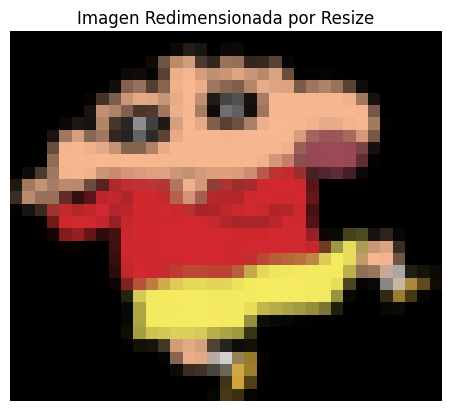


Número total de muestras (píxeles) en el dataset: 1050


In [19]:
# Obtenemos las coordenadas y colores de la imagen
coords, colors, image = get_data(image_name="shin_chan_progIA.png", target_size=(35, 30))

# Plot (Opcional, lo pongo para comparar)
plt.imshow(image.permute(1, 2, 0))  # Permute reordena las dimensiones
plt.title(f"Imagen Redimensionada por Resize")
plt.axis('off')
plt.show()

# Obtenemos la instancia del Dataset
dataset = ImageDataset(coords, colors)
print(f"\nNúmero total de muestras (píxeles) en el dataset: {len(dataset)}") # para comprobar


# Ajustamos parámetros previos al entrenamiento
batch_size = 1024                   # Tamaño del lote cercano al total (1050)
learning_rate = 0.5                 # Tasa de aprendizaje alta, buscando convergencia rápida en este problema de regresión de imagen.
epochs = 4000                       # Número elevado de épocas para permitir al MLP aprender detalles finos de la imagen.
loss_fn = torch.nn.MSELoss()        # Para predecir valores continuos de color RGB
optimizer = torch.optim.SGD


# Obtenemos el Dataloader
dataloader = DataLoader(dataset, batch_size=batch_size, shuffle=True)

Creamos el MLP:

In [7]:
class My_MLP(torch.nn.Module):
  def __init__(self, list_of_neurons, list_of_activations, device='cpu'):
    """
    Args:
      list_of_neurons (list[int]): número de neuronas por capa (incluye la de salida)
      list_of_activations (list[nn.Module]): activaciones por capa (una por cada capa)
    """
    super().__init__()
    self.list_of_layers = nn.ModuleList()
    self.list_of_activations = nn.ModuleList(list_of_activations)

    assert len(list_of_neurons) == len(list_of_activations), \
    "Debe haber una activación por cada capa lineal."

    for n in list_of_neurons:
      if len(self.list_of_layers)==0:
        self.list_of_layers.append(nn.LazyLinear(n).to(device))
      else:
        self.list_of_layers.append(nn.Linear(previous_n, n).to(device))
      previous_n = n

  def forward(self, inputs):
    outputs = None
    for layer, activation in zip(self.list_of_layers, self.list_of_activations):
      outputs = activation(layer(inputs)) if outputs is None else activation(layer(outputs))
    return outputs

Creamos la instancia del MLP:

In [8]:
list_of_neurons = [518, 518, 518, 518, 3]                     # Arquitectura MLP: 4 capas ocultas anchas (518 neuronas) para alta capacidad, 3 neuronas de salida (RGB).
list_of_activations = [nn.ReLU(), nn.ReLU(), nn.ReLU(),
                       nn.ReLU(), nn.Sigmoid()]               # Activaciones: ReLU en capas ocultas (estándar), sigmoide en salida (para colores [0,1]).
mlp = My_MLP(list_of_neurons, list_of_activations).to(device)
print("Neuronas por capa:", list_of_neurons)
print("Activaciones:", list_of_activations)
print(mlp)


Neuronas por capa: [518, 518, 518, 518, 3]
Activaciones: [ReLU(), ReLU(), ReLU(), ReLU(), Sigmoid()]
My_MLP(
  (list_of_layers): ModuleList(
    (0): LazyLinear(in_features=0, out_features=518, bias=True)
    (1-3): 3 x Linear(in_features=518, out_features=518, bias=True)
    (4): Linear(in_features=518, out_features=3, bias=True)
  )
  (list_of_activations): ModuleList(
    (0-3): 4 x ReLU()
    (4): Sigmoid()
  )
)


Configuramos el Encoder y el Optimizador


In [9]:
# --- Codificador posicional ---
encoder = Positional_Encoder(device=device, L=10)
encoded_input_dim = encoder.get_output_dim(2)       # Calcula la dimensión de la entrada codificada (para coords x, y).
print(f"Entradas del modelo: {encoded_input_dim}")
# --- Optimizador ---
opt = optimizer(
    mlp.parameters(),
    lr=learning_rate,
  )

Entradas del modelo: 42


Definimos una función entrenamiento que devuelva las pérdidas

In [10]:
def train(epochs, dataloader, opt, encoder, mlp, loss_fn, dataset):
  losses = []
  for epoch in tqdm(range(epochs), desc="Época"):
    epoch_loss = 0.0
    for coords_batch, colors_batch in dataloader:
        coords_batch = coords_batch.to(device)
        colors_batch = colors_batch.to(device)

        # 1. Codificación posicional de las coordenadas
        encoded_coords = encoder(coords_batch)

        # 2. Forward
        preds = mlp(encoded_coords)

        # 3. Cálculo de pérdida
        loss = loss_fn(preds, colors_batch)

        # 4. Backpropagation
        opt.zero_grad()
        loss.backward()
        opt.step()

        epoch_loss += loss.item() * coords_batch.size(0)  # Acumula la pérdida total del batch (pérdida_promedio * tamaño_batch) a la pérdida de la época.

    epoch_loss = epoch_loss/len(dataset)
    losses.append(epoch_loss)

    # --- Mostrar progreso ---
    if epoch % 200 == 0 or epoch == epochs - 1:
        print(f"\nÉpoca {epoch}/{epochs} - Pérdida: {epoch_loss:.6f}")
  return losses

¡Y a entrenar!

Época:   0%|          | 10/4000 [00:00<03:12, 20.73it/s]


Época 0/4000 - Pérdida: 0.163376


Época:   5%|▌         | 207/4000 [00:03<00:45, 83.23it/s]


Época 200/4000 - Pérdida: 0.019765


Época:  10%|█         | 410/4000 [00:06<00:58, 61.58it/s]

...


Época 3600/4000 - Pérdida: 0.000290


Época:  95%|█████████▌| 3802/4000 [00:56<00:02, 84.21it/s]


Época 3800/4000 - Pérdida: 0.000167


Época: 100%|██████████| 4000/4000 [01:00<00:00, 66.28it/s]



Época 3999/4000 - Pérdida: 0.000235


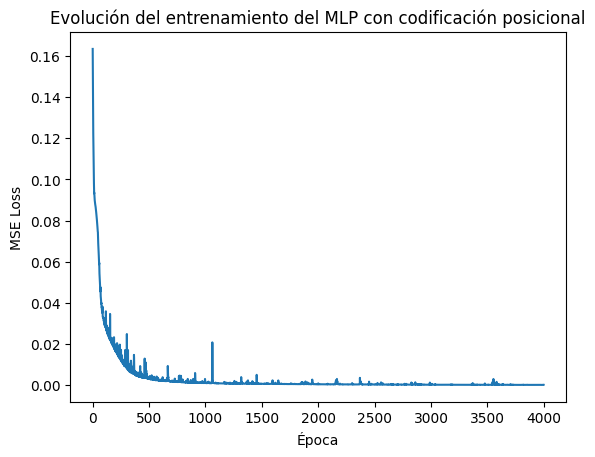

In [11]:
losses = train(epochs, dataloader, opt, encoder, mlp, loss_fn, dataset)

# --- Curva de pérdida ---
plt.plot(losses)
plt.xlabel("Época")
plt.ylabel("MSE Loss")
plt.title("Evolución del entrenamiento del MLP con codificación posicional")
plt.show()

Definimos una función para generar y observar la imagen de (W x H)

In [12]:
def generate_img(model=mlp, encoder=encoder, target_size=(35, 30), device = device):
    W, H = target_size
    xs = torch.linspace(0, 1, W)
    ys = torch.linspace(0, 1, H)
    grid_y, grid_x = torch.meshgrid(ys, xs, indexing='ij')
    coords = torch.stack([grid_x, grid_y], dim=-1)
    coords = coords.reshape(-1, 2)

    coords = coords.to(device)

    with torch.no_grad():         # Para ejecutar el modelo cuando solo necesito la salida
                                  # y no voy a entrenar, no necesito los gradientes

        encoded_coords = encoder(coords)
        preds = model(encoded_coords).reshape(H, W, 3)

    preds_cpu = preds.cpu()   # Lo mando a CPU para hacer el plot.
    plt.imshow(preds_cpu)
    title = f"Imagen generada ({W}x{H})"
    plt.title(title)
    plt.axis('off')
    plt.show()

    # It's usually better to return the CPU tensor unless needed elsewhere on GPU
    return preds_cpu

Veamos si reconstruye bien la imagen, la de (35, 30)

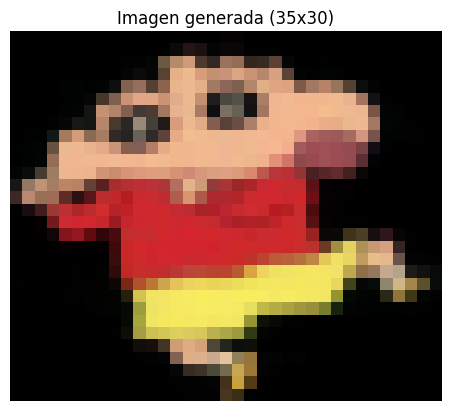

In [13]:
new_img_35x30 = generate_img(mlp, encoder, target_size=(35, 30))

Nada mal, es un primer paso. Probemos ahora con (70, 60)

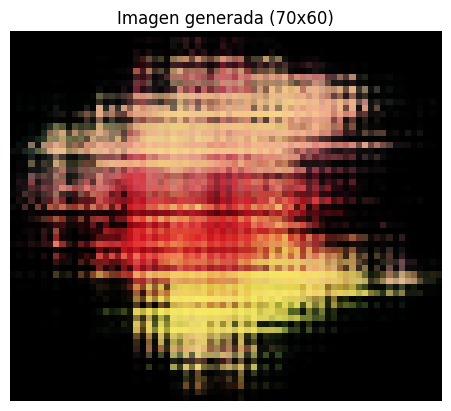

In [14]:
new_img_70x60 = generate_img(mlp, encoder, target_size=(70, 60))

### ¿Por qué la imagen de 70x60 sale mal? El Sobreajuste de Coordenadas

Lo que estamos viendo en la imagen de 70x60 es un caso clásico de **sobreajuste (overfitting)**, pero de un tipo muy específico y sutil.

#### 1. El Problema: Memorización de Coordenadas de Alta Frecuencia

* **Entrenamiento Discreto:** Durante el entrenamiento, alimentamos al `DataLoader` siempre con la **misma rejilla** de 1050 coordenadas exactas (por ejemplo, `(x=0.0345, y=0.0)`).
* **Codificador Demasiado Potente:** El `Positional_Encoder` con `L=10` es *extremadamente potente*. Genera características de muy alta frecuencia.
* **Memorización:** Esta combinación le da al modelo una capacidad tan grande que, en lugar de aprender la *forma general* y continua de la imagen, le resulta más fácil **memorizar** la respuesta de color exacta para cada uno de esos 1050 puntos discretos.
* **Fallo en la Generalización:** Cuando pedimos la imagen de 70x60, le estamos pasando 4200 coordenadas, la mayoría de las cuales son *nuevas* (p.ej., `x=0.0169`) y nunca las vio en el entrenamiento. Como el modelo solo sabe "memorizar" los puntos originales, la función que aprendió es caótica y ruidosa *entre* esos puntos. No aprendió la función continua subyacente.

---

#### 2. La Solución: Regularizar Reduciendo la Frecuencia (Bajar L)

Una solución sencilla es **reducir la capacidad de memorización** del modelo. Esto es una forma de **regularización**.

* **La Causa:** El problema es causado por las altas frecuencias del codificador.
* **La Acción:** Si **reducimos el valor de `L`** (por ejemplo, a `L=5` o `L=6`) en la celda donde definimos el `encoder` para el entrenamiento, estamos eliminando esas características de alta frecuencia.
* **El Efecto:** Sin esa capacidad para "ver" detalles tan finos, el modelo ya no puede memorizar cada píxel individualmente. Se ve **forzado a aprender una función más simple y suave** (de baja frecuencia) que represente la forma general de la imagen.
* **El Resultado:** Esta función más suave sí sabe cómo **interpolar** correctamente entre los puntos. Al generar la imagen de 70x60, el resultado ya no será ruidoso.

In [15]:
mlp = My_MLP(list_of_neurons, list_of_activations).to(device)
encoder = Positional_Encoder(device=device, L = 5)
opt = optimizer(
    mlp.parameters(),
    lr=learning_rate,
    momentum=0.9
  )

Época:   0%|          | 17/4000 [00:00<00:48, 82.61it/s]


Época 0/4000 - Pérdida: 0.164238


Época:   5%|▌         | 219/4000 [00:02<00:46, 80.85it/s]


Época 200/4000 - Pérdida: 0.001612


Época:  10%|█         | 410/4000 [00:05<00:42, 84.89it/s]

...


Época 3600/4000 - Pérdida: 0.000004


Época:  95%|█████████▌| 3812/4000 [00:50<00:03, 62.44it/s]


Época 3800/4000 - Pérdida: 0.000006


Época: 100%|██████████| 4000/4000 [00:53<00:00, 75.15it/s]



Época 3999/4000 - Pérdida: 0.000004


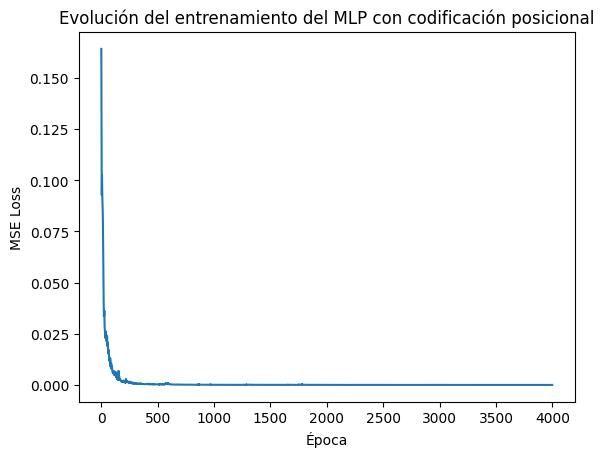

In [16]:
losses = train(epochs, dataloader, opt, encoder, mlp, loss_fn, dataset)

# --- Curva de pérdida ---
plt.plot(losses)
plt.xlabel("Época")
plt.ylabel("MSE Loss")
plt.title("Evolución del entrenamiento del MLP con codificación posicional")
plt.show()

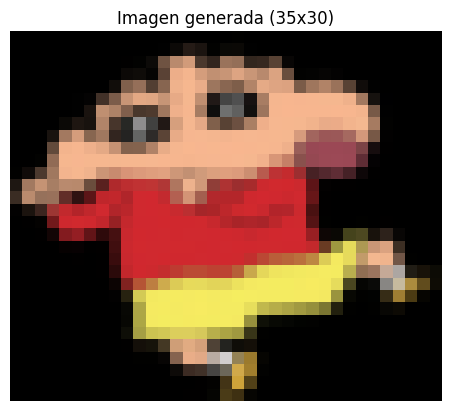

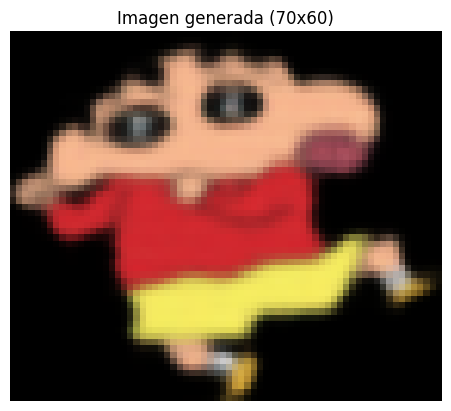

In [17]:
new_img_35x30 = generate_img(mlp, encoder, target_size=(35, 30))
new_img_70x60 = generate_img(mlp, encoder, target_size=(70, 60))